<a href="https://colab.research.google.com/github/ianmccall13/Tracking-Tendon-Fibers/blob/main/TrackingTendonFibers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q git+https://github.com/ultralytics/ultralytics.git
!pip install -q git+https://github.com/facebookresearch/segment-anything-2.git
!pip install -q supervision open3d

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 373.3/373.3 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8

In [ ]:
import os
import cv2
import torch
import base64
import numpy as np
import supervision as sv
import matplotlib.pylab as plt
import matplotlib.pyplot as plot
import plotly.graph_objects as go
import plotly.express as px
import open3d as o3d
from pathlib import Path
from supervision.assets import download_assets, VideoAssets
from torchvision import transforms
from PIL import Image
from ultralytics import YOLO
from sam2.build_sam import build_sam2_video_predictor
from google.colab import files

HOME = os.getcwd()

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# User Customization

In [ ]:
#Global Variables for Pipeline Customization:
  #frameSkip: The size of a group of frames that the system pulls 1 from to reduce the input size, if you want all input processed frameSkip = 1, if you want every other frame frameSkip = 2, etc.
  #fps: The frames per second of the output video, you may want to alter this value depending on the number of frames you are processing.
  #SCALE_FACTOR: The scale of the output video's dimensions relative to the input, SCALE_FACTOR = 1 meanings the video will have same size as the input, SCALE_FACTOR = 2 would double the video's dimensions relative to the input.
  #scale_unit: The unit and 'stretch' factor on the z-axis in the final reconstruction. MUST BE "millimeters", "microns", or "pixels". Check the
frameSkip = 1
fps = 8
SCALE_FACTOR = 1
scale_unit = "microns"
# Physical calibration: set these to your scan's voxel size (um per pixel in-plane,
# um per slice in z). E.g. the P21 high-resolution scans of Ditton et al. (2024)
# use 9 um isotropic voxels; their P50 HR scans use ~7 um.
MICRONS_PER_PIXEL = 9.0
MICRONS_PER_ZSTEP = 9.0


In [ ]:
#Run this cell and then click "Choose Files" and add your zip of input images (TIFF, BMP, PNG or JPEG slices)
uploaded = files.upload()

Saving OneDrive_6_8-4-2026.zip to OneDrive_6_8-4-2026.zip


In [ ]:
#Create working directories for the pipeline
os.makedirs('/content/INPUT', exist_ok=True)
os.makedirs('/content/INTERMEDIATE', exist_ok=True)
os.makedirs('/content/OUTPUT', exist_ok=True)

#Place the model weights in a isolated folder to use when running the models
os.makedirs(f"{HOME}/checkpoints", exist_ok=True)
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt -P {HOME}/checkpoints
!wget -O {HOME}/checkpoints/fiberYOLO26Weights.pt https://github.com/Boyu-Zhang-UOI/INBRE-AI-Tendon/raw/main/fiberYOLO26Weights.pt
assert os.path.getsize(f"{HOME}/checkpoints/fiberYOLO26Weights.pt") > 1_000_000, \
    "detector weights failed to download - check the URL above"

In [ ]:
zip_filename = list(uploaded.keys())[0]
!unzip -o -q -j "{zip_filename}" -x "__MACOSX/*" ".*" -d /content/INPUT

caution: excluded filename not matched:  __MACOSX/*
caution: excluded filename not matched:  .*


In [ ]:
if torch.cuda.get_device_properties(0).major >= 8:
  torch.backends.cuda.matmul.allow_tf32 = True
  torch.backends.cudnn.allow_tf32 = True

#Model setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT1 = f"{HOME}/checkpoints/fiberYOLO26Weights.pt"
CHECKPOINT2 = f"{HOME}/checkpoints/sam2_hiera_large.pt"
CONFIG = "sam2_hiera_l.yaml"
yolo_model = YOLO(CHECKPOINT1)
sam2_model = build_sam2_video_predictor(CONFIG, CHECKPOINT2)

# Data Preparation and Preprocessing Functions

In [ ]:
#Function that turns a folder of image files (TIFF/BMP/PNG/JPEG) into a folder of JPEG files and skips input based on frameSkip parameter
def tiff_to_jpeg(inputPath, outputPath, frameSkip):
  if not os.path.exists(outputPath):
    os.makedirs(outputPath)
  #Collect all tiffs and sort them
  IMAGE_EXTS = (".tif", ".tiff", ".bmp", ".png", ".jpg", ".jpeg")
  inputFiles = [img for img in os.listdir(inputPath) if img.lower().endswith(IMAGE_EXTS)]
  inputFiles.sort()
  # Skip scanner preview/auxiliary files (e.g. *_spr.tif) and any frame whose
  # dimensions differ from the first slice -- a stray odd-sized file makes the
  # SAM2 video loader record wrong video dimensions and silently corrupts all
  # box prompts downstream.
  refSize = None
  cleaned = []
  for img in inputFiles:
    if "_spr" in img.lower():
      print(f"Skipping scanner preview file: {img}")
      continue
    try:
      size = Image.open(os.path.join(inputPath, img)).size
    except Exception:
      print(f"Skipping unreadable file: {img}")
      continue
    if refSize is None:
      refSize = size
    if size != refSize:
      print(f"Skipping {img}: size {size} does not match stack size {refSize}")
      continue
    cleaned.append(img)
  inputFiles = cleaned
  for i, filename in enumerate(inputFiles):
    #Skip through all unwanted frames
    if i % frameSkip != 0:
            continue
    if filename.lower().endswith(IMAGE_EXTS):
      imagePath = os.path.join(inputPath, filename)
      #make an empty jpeg with the sequential intname as the input images
      newName = f"{i:05}.jpeg"
      interPath = os.path.join(outputPath, newName)
      #Convert the tiff to a jpeg
      try:
          image = Image.open(imagePath)
          if image.mode in ['I;16', 'I']:
            imageMod = np.array(image, dtype=np.uint16)
            imageMod = (imageMod / 256).astype(np.uint8)
            image = Image.fromarray(imageMod)
          image = image.convert('RGB')
          image.save(interPath, 'JPEG', quality=95)
      except Exception as image:
        print(f"Error converting '{filename}': {image}")

#Function that turns a folder of JPEG files into a MP4 with with the specificied fps
def jpeg_to_mp4(inputPath, outputPath, fps):
  #Collect all jpegs and sort them
  inputFiles = [img for img in os.listdir(inputPath) if img.endswith(".jpg") or img.endswith(".jpeg")]
  inputFiles.sort()
  if not inputFiles:
    print("No JPEG files found")
    return
  #establish framerate, width, and height of video based on first jpeg
  firstImagePath = os.path.join(inputPath, inputFiles[0])
  frame = cv2.imread(firstImagePath)
  height, width, _ = frame.shape
  fourcc = cv2.VideoWriter_fourcc(*'mp4v')
  video = cv2.VideoWriter(outputPath, fourcc, fps, (width, height))
  #Compile all the frames
  for i, inputFrame in enumerate(inputFiles):
    framePath = os.path.join(inputPath, inputFrame)
    frame = cv2.imread(framePath)
    if frame is None:
      print(f"Error reading frame {frame_path}, skipping it")
      continue
    video.write(frame)
  video.release()

#Function that loops through all images in inputPath and sharpens them
def sharpen_images(inputPath, outputPath):
  if not os.path.isdir(inputPath):
      print(f"Error: Folder not found at '{inputPath}'")
  else:
      print(f"Searching for images in: {inputPath}")
      # Define acceptable image extensions
      image_extensions = ('.png', '.jpg', '.jpeg')
      for i, filename in enumerate(os.listdir(inputPath)):
          # path to the file
          full_file_path = os.path.join(inputPath, filename)
          # Filter to ensure we only process actual image files
          if os.path.isfile(full_file_path) and filename.lower().endswith(image_extensions):
              # Read the image into a NumPy array using OpenCV
              tendon_img = cv2.imread(full_file_path)
              # Check if image was read successfully (e.g., not a corrupted file)
              if tendon_img is None:
                  print(f"Warning: Could not read image file {filename}. Skipping.")
                  continue
              # Sharpening Kernel (this is correct)
              kernel_sharpening = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
              # Apply the filter to the actual image data (tendon_img)
              sharpened = cv2.filter2D(tendon_img, -1, kernel_sharpening)
              # Save the sharpened image
              sharpPath = os.path.join(outputPath, f"{filename}")
              cv2.imwrite(sharpPath, sharpened)
              #print(f"Saved sharpened image to: {output_path}")
          elif not filename.startswith('.'): # Skip hidden files, but print a message for others
              print(f"Skipping non-image file: {filename}")

## Configure the Intermediate Folder

In [ ]:
INPUT = '/content/INPUT'
INTERMEDIATE = '/content/INTERMEDIATE'
OUTPUT = '/content/OUTPUT'
INTERMEDIATE_VIDEO = OUTPUT + "/Intermediate_Video.mp4"
OUTPUT_VIDEO = OUTPUT + "/Output_Video.mp4"

tiff_to_jpeg(INPUT, INTERMEDIATE, frameSkip) #Problem: Sometimes images are already .jpg format. Account for this.
sharpen_images(INTERMEDIATE, INTERMEDIATE)
jpeg_to_mp4(INTERMEDIATE, INTERMEDIATE_VIDEO, fps)

INTERMEDIATE_PATHS = sorted(sv.list_files_with_extensions((Path(HOME) / Path(INTERMEDIATE)).as_posix(), extensions=["jpg", "jpeg"]))

Searching for images in: /content/INTERMEDIATE


In [ ]:
#instantiate the SAM model
# Offload the video frames and inference state to CPU memory so that long
# stacks fit in GPU memory (727 full-resolution slices ran within 20 GB VRAM;
# without offloading, GPU memory grows with sequence length and object count).
inference_state = sam2_model.init_state(video_path=INTERMEDIATE, offload_video_to_cpu=True, offload_state_to_cpu=True)
sam2_model.reset_state(inference_state)

frame loading (JPEG): 100%|██████████| 312/312 [00:26<00:00, 11.62it/s]


In [ ]:
import numpy as np

SEED_DEDUP_IOU = 0.7  # YOLO26 is NMS-free: suppress near-duplicate boxes on the same fascicle


def dedup_boxes(xyxy, conf, iou_thr=SEED_DEDUP_IOU):
    """Greedy suppression: of any two boxes with IoU >= iou_thr keep the higher-confidence one.

    Returns the indices to keep, in descending confidence order.
    """
    xyxy = np.asarray(xyxy, dtype=float)
    keep = []
    for i in np.argsort(-np.asarray(conf)):
        a = xyxy[i]
        duplicate = False
        for j in keep:
            b = xyxy[j]
            inter = max(0.0, min(a[2], b[2]) - max(a[0], b[0])) * max(0.0, min(a[3], b[3]) - max(a[1], b[1]))
            union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
            if union > 0 and inter / union >= iou_thr:
                duplicate = True
                break
        if not duplicate:
            keep.append(int(i))
    return keep

with torch.no_grad():
  with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
    FRAME_IDX = 0
    FRAME_PATH = Path(INTERMEDIATE) / f"{FRAME_IDX:05d}.jpeg"
    results = yolo_model(FRAME_PATH) #detect tendons

    # YOLO26 is NMS-free and can return two near-identical boxes on one fascicle;
    # keep only the higher-confidence box of any overlapping pair before seeding SAM2.
    det = results[0].boxes
    xyxy_all = det.xyxy.cpu().numpy()
    conf_all = det.conf.cpu().numpy()
    keep = dedup_boxes(xyxy_all, conf_all)
    print(f"seeding {len(keep)} objects ({len(xyxy_all) - len(keep)} duplicate detections suppressed)")

    #perform an initial segmentation
    for obj_id, k in enumerate(keep):
        _, object_ids, mask_logits = sam2_model.add_new_points_or_box(inference_state=inference_state, frame_idx=FRAME_IDX, obj_id=obj_id, box=xyxy_all[k].tolist(), clear_old_points=True, normalize_coords=True,)


image 1/1 /content/INTERMEDIATE/00000.jpeg: 640x640 41 Fibers, 16.2ms
Speed: 9.8ms preprocess, 16.2ms inference, 23.8ms postprocess per image at shape (1, 3, 640, 640)


/usr/local/lib/python3.12/dist-packages/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/usr/local/lib/python3.12/dist-packages/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


In [ ]:
import os
import cv2
import torch
import base64
import numpy as np
import supervision as sv
import matplotlib.pylab as plt
import matplotlib.pyplot as plot
import plotly.graph_objects as go
import plotly.express as px
import open3d as o3d
from pathlib import Path
from supervision.assets import download_assets, VideoAssets
from torchvision import transforms
from PIL import Image
from ultralytics import YOLO
from sam2.build_sam import build_sam2_video_predictor
from google.colab import files

HOME = os.getcwd()


#Tracking Fibers through frames
video_info = sv.VideoInfo.from_video_path(INTERMEDIATE_VIDEO)
video_info.width = int(video_info.width * SCALE_FACTOR)
video_info.height = int(video_info.height * SCALE_FACTOR)
COLORS = ['#FF1493', '#00BFFF', '#FF6347', '#FFD700']
mask_annotator = sv.MaskAnnotator(
    color=sv.ColorPalette.from_hex(COLORS),
    color_lookup=sv.ColorLookup.CLASS)
OUTPUT_IMAGES = Path(HOME) / OUTPUT
frame_sample = []
mask_list = []
targets = {}


with sv.VideoSink(Path(OUTPUT_VIDEO).as_posix(), video_info=video_info) as sink:
    for frame_idx, object_ids, mask_logits in sam2_model.propagate_in_video(inference_state):

        frame_path = INTERMEDIATE_PATHS[frame_idx]
        frame = cv2.imread(frame_path)

        # Define target dimensions for resizing based on output video info
        target_height, target_width = video_info.height, video_info.width

        # Resize frame to target dimensions if it's not already, before annotation
        if frame.shape[0] != target_height or frame.shape[1] != target_width:
            frame = cv2.resize(frame, (target_width, target_height), interpolation=cv2.INTER_AREA)

        raw_masks = (mask_logits > 0.0).cpu().numpy()
        raw_masks_squeezed = np.squeeze(raw_masks)

        resized_masks_list = []
        # Iterate through each individual mask (if multiple exist) or just the single mask
        if raw_masks_squeezed.ndim == 2: # It's a single mask (H_model, W_model)
            mask_to_resize = raw_masks_squeezed
            resized_mask = cv2.resize(mask_to_resize.astype(np.uint8), (target_width, target_height), interpolation=cv2.INTER_NEAREST)
            resized_masks_list.append(resized_mask)
            combined_mask_for_list = resized_mask # If only one mask, it is the combined mask
        elif raw_masks_squeezed.ndim == 3: # It's multiple masks (N, H_model, W_model)
            for m in raw_masks_squeezed:
                resized_m = cv2.resize(m.astype(np.uint8), (target_width, target_height), interpolation=cv2.INTER_NEAREST)
                resized_masks_list.append(resized_m)
            combined_mask_for_list = np.any(np.array(resized_masks_list), axis=0) # Combine all resized masks
        else:
            raise ValueError("Unexpected mask dimensions after squeeze")

        # Convert the list of resized masks back to a (N, H_frame, W_frame) boolean array
        masks_for_detections = np.array(resized_masks_list).astype(bool)

        # Ensure it's 3D even for a single mask for consistency with sv.Detections
        if masks_for_detections.ndim == 2:
            masks_for_detections = masks_for_detections[np.newaxis, :, :]


        # Fiber mask collection (for mask_list)
        mask_list.append((combined_mask_for_list.astype(np.uint8) * 255))

        # Bounding box collection for targets
        detections = sv.Detections(
            xyxy=sv.mask_to_xyxy(masks=masks_for_detections),
            mask=masks_for_detections,
            class_id=np.array(object_ids)
        )

        for i, obj_id in enumerate(object_ids):
            if obj_id not in targets:
                targets[obj_id] = []
            targets[obj_id].append(detections.xyxy[i])

        annotated_frame = mask_annotator.annotate(scene=frame.copy(), detections=detections)
        annotated_frame_path = OUTPUT_IMAGES / f"Annotated{frame_idx:05d}.jpeg"
        cv2.imwrite(annotated_frame_path.as_posix(), annotated_frame)
        sink.write_frame(annotated_frame)
        #For the sample output image
        frame_sample.append(annotated_frame)

targets = {k: np.array(v) for k, v in targets.items()}
masks = mask_list
print(f"Successfully collected {len(masks)} masks and {len(targets)} fiber targets.")
masks_3d_array = np.array(masks)
reconstructionPath = OUTPUT +"/points3D.npz"
np.savez_compressed(reconstructionPath, masks_3d_array)


propagate in video: 100%|██████████| 312/312 [12:14<00:00,  2.35s/it]


Successfully collected 312 masks and 41 fiber targets.


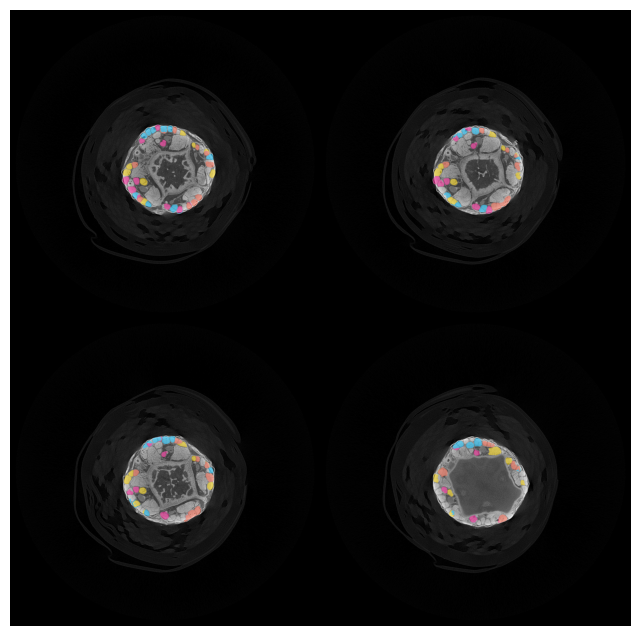

In [ ]:
#Create a sample output image that has 4 annotated frames in a grid pattern
if(len(INTERMEDIATE_PATHS) >= 10):
  image_arrays = [frame_sample[0], frame_sample[int(len(frame_sample) / 4)], frame_sample[int(len(frame_sample) / 2)],frame_sample[len(frame_sample) - 1]]
  fig, axes = plot.subplots(2, 2, figsize=(8, 8))
  plot.subplots_adjust(wspace=0, hspace=0)

  for i, ax in enumerate(axes.flat):
    if i < len(image_arrays):
        img_array = image_arrays[i]
        image_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
        ax.imshow(image_rgb, origin='upper', aspect='auto')
        ax.axis('off')

  plot.savefig( OUTPUT + '/Sample_Output.png', bbox_inches='tight', pad_inches=0.01)
  plot.show()


# 3D Reconstruction (Point Cloud)

In [ ]:
# This section of code focuses on generating a 3D point cloud from 2D masks across multiple z-slices.
# Each point in the cloud represents a part of a detected fiber in 3D space, with its x, y, z coordinates
# and an associated 'blob_id' to identify which fiber it belongs to.

'''
UNIT_OPTIONS = {
    "microns": 0.5,
    "millimeters": 0.001,
    "pixels": 1.0 / MICRONS_PER_PIXEL
}
UNIT_LABELS = {
    "microns": "µm",
    "millimeters": "mm",
    "pixels": "px"
}
'''

# Function to create a PLY file (Polygon File Format) from a NumPy array of points.
# The PLY file stores x, y, z coordinates and a blob_id for each vertex.
def createPointCloud(filename, arr):
    with open(filename, 'w') as file:
        file.write("ply\n")
        file.write("format ascii 1.0\n")
        num_verts = arr.shape[0]
        file.write(f"element vertex {num_verts}\n")
        file.write("property float32 x\n")
        file.write("property float32 y\n")
        file.write("property float32 z\n")
        file.write("property int32 blob_id\n")
        file.write("end_header\n")

        # Write each point's coordinates and its associated fiber ID.
        for i, point in enumerate(arr):
            file.write(f"{point[0]} {point[1]} {point[2]} {int(point[3])}\n")


# Function to add points from a 2D mask to a list of 3D points.
# It converts 2D (x, y) coordinates from the mask into 3D points by assigning a 'depth' (z-coordinate)
# and an identifier for the fiber (blob_id).
def addPoints(mask, points_list, depth, blob_id):
    # Find the (y, x) coordinates where the mask is active (value 255).
    y_indices, x_indices = np.where(mask == 255)
    # Append each found (x, y) point with its depth and blob_id to the points_list.
    for x, y in zip(x_indices, y_indices):
        points_list.append([x, y, depth, blob_id])


# Main function to process a series of 2D masks and reconstruct a 3D point cloud.
# It iterates through each mask (representing a z-slice), identifies fiber regions,
# and extracts points to build the 3D representation.
def main(targets):
    # Initialize z-step and point list.
    z_step_slices = frameSkip # Each processed frame is frameSkip slices deep; converted to um by MICRONS_PER_ZSTEP below.
    depth = 0           # Current z-coordinate.
    points = []         # List to store all 3D points.

    try:
        # Load masks data from a compressed NumPy file.
        # It tries to access 'masks' key first, then 'arr_0' for compatibility.
        data = np.load(reconstructionPath)
        print("Keys inside file:", data.files)
        masks = data['masks'] if 'masks' in data else data['arr_0']
    except FileNotFoundError:
        print("Error: reconstruction Path not found. Upload it first!")
        return None

    print(f"Processing {len(masks)} frames across {len(targets)} fibers...")

    # Initialize 'prev', 'curr', and 'after' masks for processing (current and adjacent slices).
    prev = masks[0]
    curr = masks[1]
    after = masks[2]

    # Ensure masks are in uint8 format and scaled to 0-255 if they are binary (0-1).
    curr_uint8 = curr.astype('uint8')
    if curr_uint8.max() <= 1:
        curr_uint8 *= 255

    prev_uint8 = prev.astype('uint8')
    if prev_uint8.max() <= 1:
        prev_uint8 *= 255

    after_uint8 = after.astype('uint8')
    if after_uint8.max() <= 1:
        after_uint8 *= 255

    # Iterate through the masks from the second to the second-to-last (to have 'prev' and 'after').
    for index in range(1, len(masks) - 1):
        if index % 10 == 0:
            print(f"Processing frame {index}/{len(masks)}")

        # Process each detected fiber (blob) in the current frame.
        for obj_idx, (obj_id, bbox_list) in enumerate(targets.items()):
            # Ensure the index is within the bounds of the bounding box list for the current object.
            if index >= len(bbox_list):
                continue

            # Extract and sanitize bounding box coordinates for the current object.
            x1, y1, x2, y2 = bbox_list[index].astype(int)
            x1 = max(x1, 0)
            y1 = max(y1, 0)
            x2 = min(x2, curr_uint8.shape[1])
            y2 = min(y2, curr_uint8.shape[0])

            # Create a mask specifically for the current blob within its bounding box.
            blob_mask = np.zeros_like(curr_uint8)
            blob_mask[y1:y2, x1:x2] = curr_uint8[y1:y2, x1:x2]

            # Identify and add points that are present in the current blob_mask but not in the 'previous' slice.
            # These points represent the 'leading edge' of the fiber in the current z-slice.
            prev_mask = np.zeros_like(curr_uint8)
            prev_mask[(prev_uint8 == 0) & (blob_mask == 255)] = 255
            addPoints(prev_mask, points, depth, obj_idx)

            # Identify and add points that are present in the current blob_mask but not in the 'after' slice.
            # These points represent the 'trailing edge' of the fiber in the current z-slice.
            next_mask = np.zeros_like(curr_uint8)
            next_mask[(after_uint8 == 0) & (blob_mask == 255)] = 255
            addPoints(next_mask, points, depth, obj_idx)

            # Find contours within the blob_mask to get boundary points of the fiber.
            contours, _ = cv2.findContours(blob_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
            # Add all contour points to the global list of points.
            for con in contours:
                for point in con:
                    p = point[0]
                    points.append([p[0], p[1], depth, obj_idx])

        # Increment the depth for the next z-slice.
        depth += z_step_slices

        # Shift the masks for the next iteration: current becomes previous, after becomes current.
        prev_uint8 = curr_uint8
        curr_uint8  = after_uint8
        after_uint8 = masks[index + 1]

        # Ensure the new 'after' mask is also in uint8 format and scaled.
        after_uint8 = after_uint8.astype('uint8')
        if after_uint8.max() <= 1:
            after_uint8 *= 255

    # Convert the list of points to a NumPy array for further processing.
    points = np.array(points, dtype=np.float32)
    if len(points) == 0:
        print("No points generated. Check your data.")
        return None

    # Scale the coordinates from pixels to physical units (microns).
    points[:, 0] *= MICRONS_PER_PIXEL   # X pixels -> µm
    points[:, 1] *= MICRONS_PER_PIXEL   # Y pixels -> µm
    points[:, 2] *= MICRONS_PER_ZSTEP   # Z steps -> µm

    print("Removing duplicates...")
    # Remove any duplicate points that might have been added.
    points = np.unique(points, axis=0)
    print(f"Final Point Cloud Shape: {points.shape}")
    print(f"Unique fibers: {int(np.max(points[:, 3])) + 1}")

    # Save the generated 3D point cloud to a PLY file.
    createPointCloud(OUTPUT + "/Point3DReconstruction.ply", points)
    return points

In [ ]:
# CALIBRATION VALUES: These constants define the physical dimensions corresponding to pixels and z-steps.
# They are crucial for converting pixel-based measurements into real-world units (microns).
# MICRONS_PER_PIXEL and MICRONS_PER_ZSTEP are set in the User Customization cell.

# Helper function to get a list of qualitative colors from Plotly.
# This is used to assign distinct colors to different fiber 'blobs' in the visualization.
def _get_colors(n):
    return px.colors.qualitative.Plotly


# Function to plot the 3D point cloud using Plotly.
# It takes the points in micron units and a chosen display unit for the z-axis,
# then visualizes each fiber with a unique color.
def plotPoints(points_microns, unit):
    # Define options for scaling the Z-axis based on user-selected units.
    Z_UNIT_OPTIONS = {
        "pixels":      1.0 / MICRONS_PER_ZSTEP, # Convert microns back to pixel-equivalent z-steps
        "microns":     0.25,                    # A factor for displaying microns in a visually appealing scale
        "millimeters": 2.0                      # A factor for displaying millimeters in a visually appealing scale
    }
    # Define human-readable labels for the Z-axis units.
    Z_UNIT_LABELS = {
        "pixels":      "px (z-steps)",
        "microns":     "µm",
        "millimeters": "mm"
    }

    # Select the appropriate scaling factor and label for the z-axis based on the 'unit' parameter.
    z_factor = Z_UNIT_OPTIONS[unit]
    z_label  = Z_UNIT_LABELS[unit]

    # Convert x, y coordinates from microns back to pixels for consistent display with image dimensions.
    px_coords = points_microns[:, 0] / MICRONS_PER_PIXEL
    py_coords = points_microns[:, 1] / MICRONS_PER_PIXEL
    # Apply the z-factor to the z-coordinates (which are already in microns) for display.
    pz        = points_microns[:, 2] * z_factor

    # Get unique fiber IDs and assign colors for plotting.
    unique_ids = np.unique(points_microns[:, 3]).astype(int)
    colors = _get_colors(len(unique_ids))

    # Initialize a Plotly 3D scatter plot figure.
    fig = go.Figure()
    # Iterate through each unique fiber to plot its points.
    for i, blob_id in enumerate(unique_ids):
        # Create a mask to select points belonging to the current fiber.
        mask = points_microns[:, 3] == blob_id
        # Add a 3D scatter trace for the current fiber.
        fig.add_trace(go.Scatter3d(
            x=px_coords[mask],
            y=py_coords[mask],
            z=pz[mask],
            mode='markers',
            name=f"Fiber {blob_id}", # Label for the legend
            marker=dict(size=2, opacity=0.8, color=colors[i % len(colors)]) # Marker style and color
        ))

    # Update the layout of the 3D plot, including axis labels and aspect ratio.
    fig.update_layout(
        scene=dict(
            xaxis=dict(title="Width (px)"),
            yaxis=dict(title="Height (px)"),
            zaxis=dict(title=f"Depth ({z_label})"),
            aspectmode='data' # Ensures uniform scaling across axes
        ),
        margin=dict(l=0, r=0, b=0, t=0), # Adjust plot margins
        legend=dict(title="Fibers", itemsizing='constant') # Configure legend
    )
    # Display the plot.
    fig.show()

In [ ]:
if __name__ == "__main__":
    points = main(targets)

    if points is not None and len(points) > 0:
        print("Generating Plot...")
        plotPoints(points, unit=scale_unit)

# 3D Reconstruction (Mesh Faces)

In [ ]:
all_triangles = []
all_vertices = []
all_colors = []
vertex_offset = 0

unique_blobs = np.unique(points[:, 3]).astype(int)
num_blobs = len(unique_blobs)

# Convert Plotly hex colors to RGB floats for Open3D
_palette = px.colors.qualitative.Plotly
def blob_color(idx):
    hex_color = _palette[idx % len(_palette)]
    hex_color = hex_color.lstrip('#')
    r, g, b = [int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4)]
    return [r, g, b]

# Iterate through each unique fiber (blob) to create a separate mesh
for blob_id in unique_blobs:
    # Extract points belonging to the current blob and only their 3D coordinates
    blob_pts = points[points[:, 3] == blob_id][:, :3]

    # Skip if there are not enough points to form a meaningful mesh
    if len(blob_pts) < 4:
        print(f"Blob {blob_id}: not enough points, skipping")
        continue

    # Guarded: degenerate (cocircular/cospherical) point sets make Qhull fail,
    # so any blob that cannot be reconstructed is skipped instead of crashing.
    try:
        # Create an Open3D PointCloud object from the blob's points
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(blob_pts)

        # Estimate normals for the point cloud, crucial for Poisson reconstruction.
        pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(
            radius=MICRONS_PER_ZSTEP * 3, max_nn=30))
        # Orient normals consistently to avoid issues with mesh topology
        pcd.orient_normals_consistent_tangent_plane(k=15)

        # Perform Poisson surface reconstruction to create a 3D mesh.
        print(f"Blob {blob_id}: running Poisson reconstruction...")
        mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=9)
        densities = np.asarray(densities)

        # Trim low density fringe vertices to remove noise and unwanted artifacts.
        mesh.remove_vertices_by_mask(densities < np.percentile(densities, 10))
    except Exception as e:
        print(f"Blob {blob_id}: reconstruction failed ({type(e).__name__}), skipping")
        continue

    # Check if the mesh is valid after trimming
    if len(mesh.vertices) == 0 or len(mesh.triangles) == 0:
        print(f"Blob {blob_id}: mesh empty after Poisson, skipping")
        continue

    # Get vertices and triangles from the generated mesh
    verts = np.asarray(mesh.vertices)
    # Adjust triangle indices by the current vertex offset to account for concatenation
    tris   = np.asarray(mesh.triangles) + vertex_offset
    # Assign a color to the current blob
    color = blob_color(blob_id)

    # Append the vertices, triangles, and colors to the global lists
    all_vertices.append(verts)
    all_triangles.append(tris)
    # Tile the color to match the number of vertices for the current blob
    all_colors.append(np.tile(color, (len(verts), 1)))
    # Update the vertex offset for the next blob
    vertex_offset += len(verts)

# After processing all blobs, combine all collected mesh data
if len(all_vertices) == 0:
    print("No meshes generated. Check your points array.")
else:
    all_vertices  = np.vstack(all_vertices)
    all_triangles = np.vstack(all_triangles)
    all_colors    = np.vstack(all_colors)
    triMeshPath = OUTPUT + "/Mesh3DReconstruction.ply"

    # Write the combined mesh data to a PLY file (Polygon File Format)
    with open(triMeshPath, 'w') as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {len(all_vertices)}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write("property uchar red\n")
        f.write("property uchar green\n")
        f.write("property uchar blue\n")
        f.write(f"element face {len(all_triangles)}\n")
        f.write("property list uchar int vertex_indices\n")
        f.write("end_header\n")
        # Write vertex data with color information
        for v, c in zip(all_vertices, all_colors):
            r, g, b = int(c[0]*255), int(c[1]*255), int(c[2]*255)
            f.write(f"{v[0]} {v[1]} {v[2]} {r} {g} {b}\n")
        # Write face data (triangle indices)
        for t in all_triangles:
            f.write(f"3 {t[0]} {t[1]} {t[2]}\n")

    print(f"\nSaved Mesh3DReconstruction.ply")
    print(f"Total vertices : {len(all_vertices)}")
    print(f"Total faces    : {len(all_triangles)}")

Blob 0: running Poisson reconstruction...
Blob 1: running Poisson reconstruction...
Blob 2: running Poisson reconstruction...
Blob 3: running Poisson reconstruction...
Blob 4: running Poisson reconstruction...
Blob 5: running Poisson reconstruction...
Blob 6: running Poisson reconstruction...
Blob 7: running Poisson reconstruction...
Blob 8: running Poisson reconstruction...
Blob 9: running Poisson reconstruction...
Blob 10: running Poisson reconstruction...
Blob 11: running Poisson reconstruction...
Blob 12: running Poisson reconstruction...
Blob 13: running Poisson reconstruction...
Blob 14: running Poisson reconstruction...
Blob 15: running Poisson reconstruction...
Blob 16: running Poisson reconstruction...
Blob 17: running Poisson reconstruction...
Blob 18: running Poisson reconstruction...
Blob 19: running Poisson reconstruction...
Blob 20: running Poisson reconstruction...
Blob 21: running Poisson reconstruction...
Blob 22: running Poisson reconstruction...
Blob 23: running Pois